# Modelo de predicción — Peso al nacer (Árbol de decisión)

**Entrega 2 — Modelos de predicción.** Este notebook contiene únicamente el desarrollo de mi modelo de predicción; la lectura, parseo y depuración del dataset ya se hicieron en la Entrega 1 ([notebooks/sivigila_bpn.ipynb](../notebooks/sivigila_bpn.ipynb)) y su resultado depurado se reutiliza aquí directamente.

- **Dataset**: `data/processed/sivigila_bpn_depurado.csv` (SIVIGILA — Bajo peso al nacer, Medellín, 2011-2021).
- **Variable objetivo**: `peso_nacer` (gramos) — regresión.
- **Modelo**: Árbol de decisión (`DecisionTreeRegressor`).

## 1. Carga del CSV depurado

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

RANDOM_STATE = 42

df = pd.read_csv("../data/processed/sivigila_bpn_depurado.csv")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 10187, Columnas: 18


,id,semana,edad_,sexo_,nombre_barrio,comuna,tipo_ss_,cod_ase_,fec_con_,pac_hos_,peso_nacer,talla_nacer,sem_gest,niv_edu_ma,year_,tipo_ss_label,pac_hos_label,niv_edu_ma_label
0,1,41,28.0,M,Oriente,Manrique,N,"\""\""",NaN,1,2440.0,49.0,38.0,SD,2011,No asegurado,Sí,Sin dato
1,2,41,17.0,F,NaN,Sin información,S,EPS003,NaN,1,2490.0,46.0,37.0,SD,2011,Subsidiado,Sí,Sin dato
2,3,44,19.0,F,Villa del Socorro,Santa Cruz,S,EPS003,NaN,1,2290.0,47.0,37.0,SD,2011,Subsidiado,Sí,Sin dato
3,4,47,27.0,F,Las Independencias,San Javier,S,EPS003,NaN,1,2400.0,49.0,37.0,SD,2011,Subsidiado,Sí,Sin dato
4,5,47,23.0,F,Granizal,Popular,N,"\""\""",NaN,1,2240.0,47.0,38.0,SD,2011,No asegurado,Sí,Sin dato


## 2. Selección de variables predictoras

Se excluyen explícitamente del conjunto de predictores:

- `id`: identificador, sin valor predictivo.
- `talla_nacer`: se mide en el mismo momento que `peso_nacer` y está casi perfectamente correlacionada con ella (ambas son antropometría del mismo parto). Incluirla sería **fuga de información** (`data leakage`): el modelo "predeciría" el peso a partir de una variable que en la práctica no se conoce antes del nacimiento, igual que el peso.
- `nombre_barrio`: demasiadas categorías (450+) para el tamaño del dataset y con alta proporción de faltantes; `comuna` ya captura el mismo nivel geográfico de forma más robusta.
- `fec_con_`, `cod_ase_`: fecha de consulta administrativa y código de aseguradora, sin relación causal esperada con el peso al nacer.

Predictores usados: `semana`, `year_`, `edad_` (edad materna), `sem_gest` (semanas de gestación), `sexo_`, `comuna`, `tipo_ss_label`, `pac_hos_label`, `niv_edu_ma_label`.

In [2]:
COLUMNAS_NUMERICAS = ["semana", "year_", "edad_", "sem_gest"]
COLUMNAS_CATEGORICAS = ["sexo_", "comuna", "tipo_ss_label", "pac_hos_label", "niv_edu_ma_label"]
OBJETIVO = "peso_nacer"

columnas_modelo = COLUMNAS_NUMERICAS + COLUMNAS_CATEGORICAS + [OBJETIVO]
datos_modelo = df[columnas_modelo].copy()

faltantes_antes = len(datos_modelo)
datos_modelo = datos_modelo.dropna()
print(f"Filas antes de excluir faltantes en columnas del modelo: {faltantes_antes}")
print(f"Filas después: {len(datos_modelo)} "
      f"({faltantes_antes - len(datos_modelo)} descartadas, "
      f"{(faltantes_antes - len(datos_modelo)) / faltantes_antes * 100:.2f}%)")

Filas antes de excluir faltantes en columnas del modelo: 10187
Filas después: 10178 (9 descartadas, 0.09%)


Las variables categóricas se codifican con *one-hot encoding*: un árbol de decisión no asume ningún orden entre categorías como `comuna` o `niv_edu_ma_label`, así que codificarlas como números (0, 1, 2…) induciría un orden falso.

In [3]:
X = pd.get_dummies(datos_modelo[COLUMNAS_NUMERICAS + COLUMNAS_CATEGORICAS],
                    columns=COLUMNAS_CATEGORICAS, drop_first=True)
y = datos_modelo[OBJETIVO]

print(f"Predictores finales: {X.shape[1]} columnas (tras one-hot encoding)")
X.head()

Predictores finales: 39 columnas (tras one-hot encoding)


,semana,year_,edad_,sem_gest,sexo__M,comuna_Aranjuez,comuna_Belen,comuna_Buenos Aires,comuna_Castilla,comuna_Corregimiento De Santa Elena,...,tipo_ss_label_Indeterminado,tipo_ss_label_No asegurado,tipo_ss_label_Particular,tipo_ss_label_Subsidiado,pac_hos_label_Sí,niv_edu_ma_label_Primaria,niv_edu_ma_label_Secundaria,niv_edu_ma_label_Sin dato,niv_edu_ma_label_Técnico/Tecnológico,niv_edu_ma_label_Universitario
0,41,2011,28.0,38.0,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,41,2011,17.0,37.0,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,False,False
2,44,2011,19.0,37.0,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,False,False
3,47,2011,27.0,37.0,False,False,False,False,False,False,...,False,False,False,True,True,False,False,True,False,False
4,47,2011,23.0,38.0,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False


## 3. Partición entrenamiento / prueba

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

Entrenamiento: 8142 filas
Prueba: 2036 filas


## 4. Modelo de referencia (baseline)

Antes de evaluar el árbol, se mide qué tan bien predice simplemente la **media del conjunto de entrenamiento** para cada caso. Cualquier modelo real debe superar claramente este punto de partida.

In [5]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

mae_baseline = mean_absolute_error(y_test, pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, pred_baseline))
print(f"Baseline (predice la media) -> MAE: {mae_baseline:.1f} g | RMSE: {rmse_baseline:.1f} g")

Baseline (predice la media) -> MAE: 123.7 g | RMSE: 160.6 g


## 5. Selección de profundidad del árbol (validación cruzada)

Un árbol sin límite de profundidad memoriza el ruido de entrenamiento (sobreajuste). Se prueban varias profundidades máximas con validación cruzada de 5 particiones sobre el conjunto de entrenamiento, y se elige la que minimiza el error absoluto medio (MAE).

Profundidad óptima según validación cruzada: 3


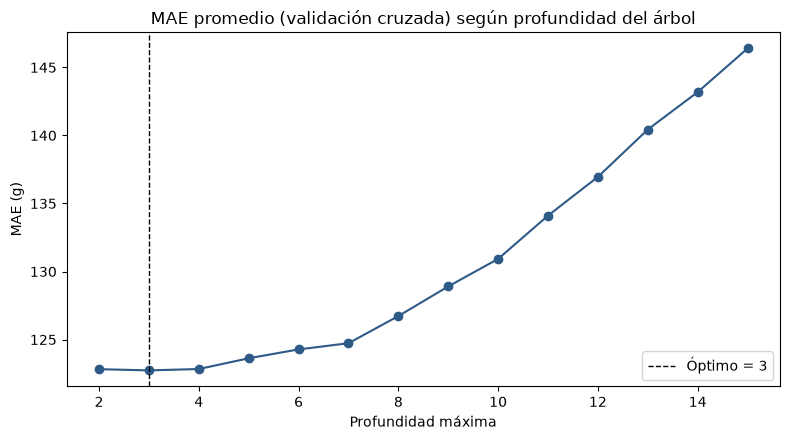

In [6]:
profundidades = range(2, 16)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

mae_por_profundidad = []
for profundidad in profundidades:
    modelo_cv = DecisionTreeRegressor(max_depth=profundidad, random_state=RANDOM_STATE)
    scores = cross_val_score(
        modelo_cv, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error"
    )
    mae_por_profundidad.append(-scores.mean())

mejor_profundidad = list(profundidades)[int(np.argmin(mae_por_profundidad))]
print(f"Profundidad óptima según validación cruzada: {mejor_profundidad}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(list(profundidades), mae_por_profundidad, marker="o", color="#2E5A87")
ax.axvline(mejor_profundidad, color="black", linestyle="--", linewidth=1,
           label=f"Óptimo = {mejor_profundidad}")
ax.set_title("MAE promedio (validación cruzada) según profundidad del árbol")
ax.set_xlabel("Profundidad máxima")
ax.set_ylabel("MAE (g)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Entrenamiento del modelo final

In [7]:
modelo = DecisionTreeRegressor(max_depth=mejor_profundidad, random_state=RANDOM_STATE)
modelo.fit(X_train, y_train)

pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)

print("Entrenado con profundidad máxima:", mejor_profundidad)

Entrenado con profundidad máxima: 3


## 7. Evaluación del modelo

In [8]:
def metricas(y_real, y_pred, nombre):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    print(f"{nombre:12s} -> MAE: {mae:6.1f} g | RMSE: {rmse:6.1f} g | R2: {r2:.3f}")
    return mae, rmse, r2

mae_train, rmse_train, r2_train = metricas(y_train, pred_train, "Entrenamiento")
mae_test, rmse_test, r2_test = metricas(y_test, pred_test, "Prueba")
print()
print(f"Mejora vs. baseline en MAE: {(1 - mae_test / mae_baseline) * 100:.1f}%")

Entrenamiento -> MAE:  122.2 g | RMSE:  163.8 g | R2: 0.060
Prueba       -> MAE:  120.2 g | RMSE:  157.8 g | R2: 0.035

Mejora vs. baseline en MAE: 2.8%


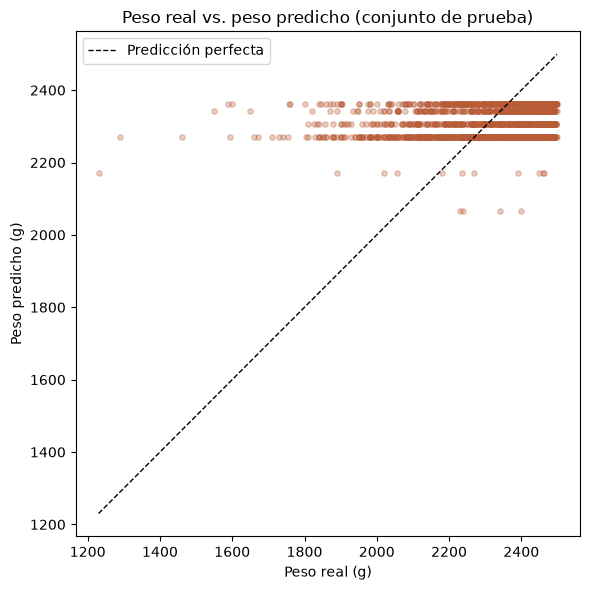

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_test, alpha=0.3, s=15, color="#B85C38")
limite = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
ax.plot(limite, limite, color="black", linestyle="--", linewidth=1, label="Predicción perfecta")
ax.set_title("Peso real vs. peso predicho (conjunto de prueba)")
ax.set_xlabel("Peso real (g)")
ax.set_ylabel("Peso predicho (g)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Importancia de variables

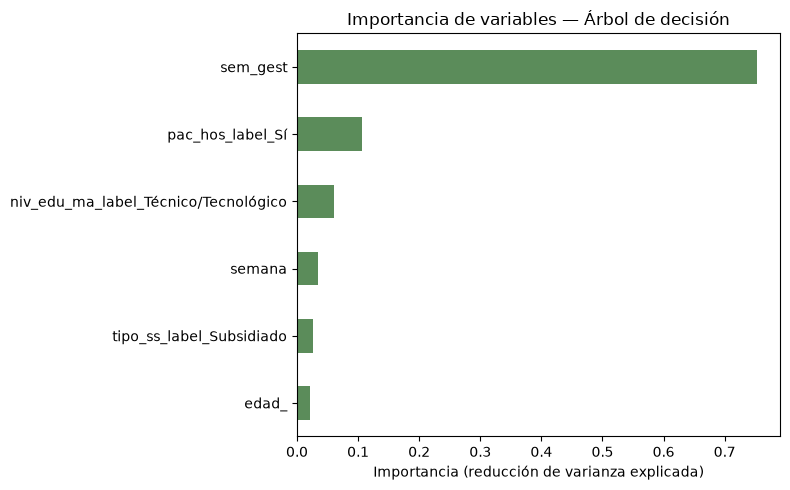

In [10]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias = importancias[importancias > 0].sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind="barh", ax=ax, color="#5B8C5A")
ax.set_title("Importancia de variables — Árbol de decisión")
ax.set_xlabel("Importancia (reducción de varianza explicada)")
plt.tight_layout()
plt.show()

## 9. Visualización del árbol (versión interpretable, profundidad 3)

El árbol final tiene la profundidad óptima encontrada en la sección 5, que puede ser difícil de leer completa. Para inspección visual se entrena una versión adicional, limitada a profundidad 3, solo con fines de interpretación (no es el modelo evaluado arriba).

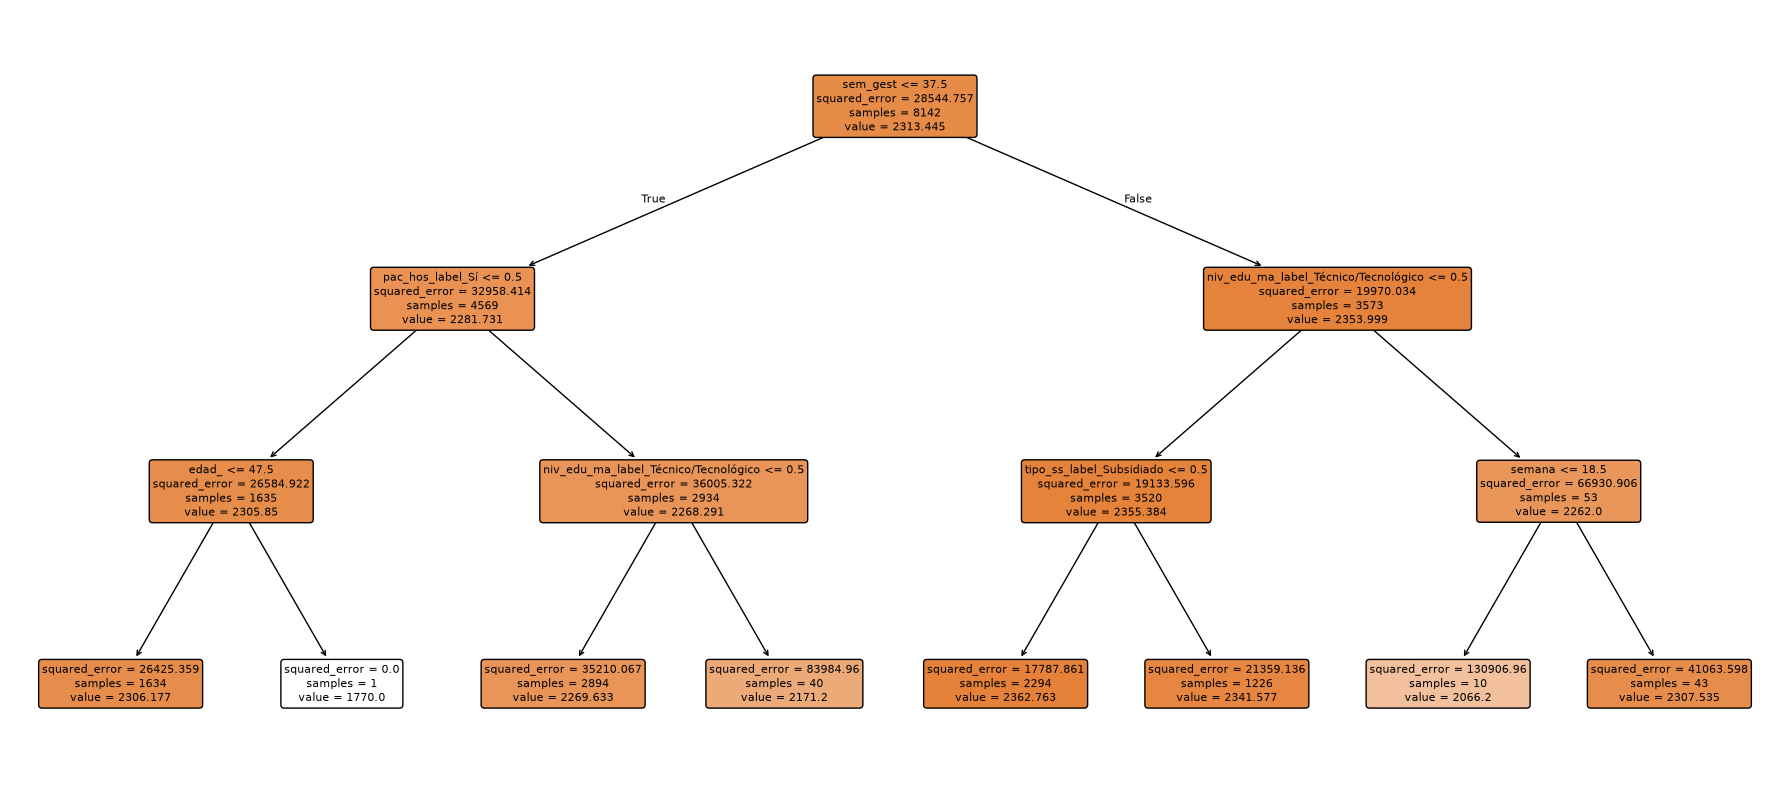

In [11]:
modelo_interpretable = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
modelo_interpretable.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
    modelo_interpretable,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
plt.tight_layout()
plt.show()

# Hallazgos y conclusiones

- El árbol de decisión (profundidad óptima = 3, elegida por validación cruzada
  de 5 particiones) obtiene **MAE = 120.2 g** y **R² = 0.035** en el conjunto
  de prueba, apenas un **2.8% mejor** que el baseline que solo predice la
  media (MAE = 123.7 g).
- Esto **no es una falla del modelo**: es consecuencia directa de cómo está
  construido el dataset. El evento SIVIGILA "bajo peso al nacer" solo incluye
  casos con `peso_nacer` menor a 2500 g (de hecho el máximo observado es
  2499 g, justo en el límite de la definición), así que la variable objetivo
  llega con muy poca variabilidad: desviación estándar de apenas ~169 g sobre
  un rango de 900 a 2499 g. Es el mismo fenómeno de **restricción de rango**
  que se documentó en la Entrega 1 al encontrar una correlación débil
  (r=0.19) entre semanas de gestación y peso.
- La variable más importante para el árbol es, con una diferencia enorme,
  `sem_gest` (**75% de la importancia total**): a menor edad gestacional,
  menor peso, incluso dentro de este subgrupo ya restringido a bajo peso.
  Le siguen `pac_hos_label` (hospitalización, 10.6%) y `niv_edu_ma_label`
  técnico/tecnológico (6.0%); `comuna` y `year_` no aportan nada a este
  árbol en particular.
- Las variables sociodemográficas y administrativas (comuna, tipo de
  aseguramiento, nivel educativo materno) aportan muy poco a predecir el
  peso exacto en gramos, aunque en la Entrega 1 sí mostraron relación con
  *cuántos* casos de bajo peso ocurren por comuna. Es decir: ayudan a
  explicar **quién** tiene más riesgo de bajo peso al nacer, no **cuánto**
  va a pesar exactamente un bebé que ya se sabe que nació con bajo peso.
- **Conclusión práctica**: para predecir `peso_nacer` con mayor precisión
  haría falta trabajar sobre la población general de nacimientos (incluyendo
  los de peso normal), donde sí existe suficiente variabilidad para que las
  variables sociodemográficas expliquen diferencias grandes. Sobre este
  subconjunto ya filtrado a bajo peso al nacer, el árbol confirma que la
  variable clínica (semanas de gestación) domina la predicción, y el margen
  de mejora frente a un modelo trivial es pequeño pero real y medible.
